
# NS-AIME Tabular Rule/Explanation Graph Demo

This notebook applies the XAI 2026 **NS-AIME** pipeline to a more rule-like tabular dataset.



In [1]:

# ============================================================
# 0. Install / import ns_aime_xai2026
# ============================================================
# In Colab, upload ns_aime_xai2026-0.2.0.tar.gz to /content first if needed.

import os, glob, sys, subprocess, warnings
warnings.filterwarnings("ignore")

try:
    import ns_aime_xai2026
except Exception:
    candidates = (
        glob.glob("/content/ns_aime_xai2026*.tar.gz")
        + glob.glob("/content/ns_aime_xai2026*.whl")
        + glob.glob("./ns_aime_xai2026*.tar.gz")
        + glob.glob("./ns_aime_xai2026*.whl")
    )
    if len(candidates) == 0:
        raise RuntimeError(
            "ns_aime_xai2026 is not installed. "
            "Please upload ns_aime_xai2026-0.2.0.tar.gz to /content and rerun this cell."
        )
    print("Installing:", candidates[0])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", candidates[0]])
    import ns_aime_xai2026

from ns_aime_xai2026 import (
    NSAIME,
    compute_metrics,
    plot_logic_graph,
    plot_dual_report,
    render_logic_graph_html,
)

print("ns_aime_xai2026", ns_aime_xai2026.__version__)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS = os.path.abspath("./results/ns_aime_tabular_rule_demo")
os.makedirs(RESULTS, exist_ok=True)
print("RESULTS =", RESULTS)


Installing: /content/ns_aime_xai2026-0.2.0.tar.gz
ns_aime_xai2026 0.2.0
RESULTS = /content/results/ns_aime_tabular_rule_demo



## 1. Dataset: Adult Income

This dataset is suitable for a rule-like tabular demonstration because it includes interpretable categorical and numerical attributes such as:

- `education`
- `occupation`
- `relationship`
- `marital-status`
- `hours-per-week`
- `capital-gain`
- `age`

The goal is not to learn a rule-based predictor.  
The goal is to convert the AIME explanation matrix into an auditable directed Explanation Graph.


In [2]:

# ============================================================
# 1. Load Adult Income from OpenML
# ============================================================
from sklearn.datasets import fetch_openml

adult = fetch_openml("adult", version=2, as_frame=True)
df = adult.frame.copy()

# Normalize column names
df.columns = [c.lower().replace(" ", "_") for c in df.columns]

# Target column can be named "class" in OpenML Adult
target_col = "class"
df[target_col] = df[target_col].astype(str).str.strip()
df[target_col] = df[target_col].str.replace(".", "", regex=False)

# Remove missing-like values
df = df.replace("?", np.nan).dropna().reset_index(drop=True)

# Optional sampling for Colab speed
N_SAMPLE = 6000
if len(df) > N_SAMPLE:
    df = df.sample(N_SAMPLE, random_state=42).reset_index(drop=True)

y = (df[target_col] == ">50K").astype(int).values
class_names = ["<=50K", ">50K"]

X_df = df.drop(columns=[target_col])

print("df shape:", df.shape)
print("target counts:")
print(pd.Series(y).map({0:"<=50K", 1:">50K"}).value_counts())
X_df.head()


df shape: (6000, 15)
target counts:
<=50K    4553
>50K     1447
Name: count, dtype: int64


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,19,Self-emp-not-inc,30800,10th,6,Married-spouse-absent,Adm-clerical,Unmarried,Amer-Indian-Eskimo,Female,0,0,40,United-States
1,45,Private,26781,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States
2,47,Private,431515,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States
3,23,Private,45713,Some-college,10,Never-married,Craft-repair,Other-relative,White,Male,0,0,40,United-States
4,53,Local-gov,175897,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States


In [3]:

# ============================================================
# 2. Preprocess into a numeric tabular matrix
# ============================================================
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

categorical_cols = X_df.select_dtypes(include=["category", "object"]).columns.tolist()
numeric_cols = [c for c in X_df.columns if c not in categorical_cols]

print("numeric:", numeric_cols)
print("categorical:", categorical_cols)

# Compatibility with different sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", ohe),
        ]), categorical_cols),
    ],
    remainder="drop",
)

X = preprocess.fit_transform(X_df).astype(float)

# Feature names
num_names = numeric_cols
cat_encoder = preprocess.named_transformers_["cat"].named_steps["onehot"]
cat_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()
feature_names = num_names + cat_names

print("X:", X.shape)
print("number of feature names:", len(feature_names))
feature_names[:20]


numeric: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
X: (6000, 103)
number of feature names: 103


['age',
 'fnlwgt',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'workclass_Federal-gov',
 'workclass_Local-gov',
 'workclass_Private',
 'workclass_Self-emp-inc',
 'workclass_Self-emp-not-inc',
 'workclass_State-gov',
 'workclass_Without-pay',
 'education_10th',
 'education_11th',
 'education_12th',
 'education_1st-4th',
 'education_5th-6th',
 'education_7th-8th',
 'education_9th']


## 2. Train black-box models

We train ordinary classifiers and explain their predicted probability matrix \(\hat{Y}=f(X)\).

For the poster explanation, one model is enough.  
Here we compare Logistic Regression, Random Forest, and LightGBM if available.


In [4]:

# ============================================================
# 3. Train black-box models
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

models = {
    "LogisticReg": LogisticRegression(max_iter=3000, solver="lbfgs"),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=8, random_state=42, n_jobs=-1
    ),
}

try:
    import lightgbm as lgb
    models["LightGBM"] = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=-1, verbose=-1, random_state=42
    )
except Exception as e:
    print("LightGBM unavailable -> skipping:", e)

for name, model in models.items():
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    print(
        f"{name:14s} "
        f"acc={accuracy_score(y_te, pred):.3f} "
        f"auc={roc_auc_score(y_te, proba):.3f}"
    )


LogisticReg    acc=0.838 auc=0.889
RandomForest   acc=0.849 auc=0.902
LightGBM       acc=0.852 auc=0.900



## 3. NS-AIME: From Matrix to Explanation Graph

The core pipeline is:

$
A^\dagger
\rightarrow
\text{rule induction}
\rightarrow
B^*
\rightarrow
\text{directed Explanation Graph}.
$

The graph is not a replacement for the raw explanation.  
The raw AIME matrix \(A^\dagger\) and the constrained matrix \(B^\*\) are reported together.


In [6]:

# ============================================================
# 4. Run NS-AIME for each model
# ============================================================
rows = []
explainers = {}

for name, model in models.items():
    Yhat = model.predict_proba(X_tr)

    # top_k controls how many important features are used for rule induction.
    # For tabular rule graphs, 6--10 is usually readable.
    ex = NSAIME(
        alpha=1.0,
        beta=4.0,
        gamma=0.05,
        top_k=8,
        normalize=True,
    )

    ex.fit(
        X_tr,
        Yhat,
        feature_names=feature_names,
        class_names=class_names,
    )

    try:
        B = ex.optimize()
    except TypeError:
        B = ex.optimize(X_tr)

    raw = compute_metrics(ex.A_dagger_, ex.A_dagger_, ex._Xp_cache, ex.rules_)
    ns = compute_metrics(B, ex.A_dagger_, ex._Xp_cache, ex.rules_)

    explainers[name] = (ex, B, raw, ns)

    rows.append([
        name,
        raw["rs"],
        ns["rs"],
        ns["rd"],
        ns["ga"],
    ])

summary = pd.DataFrame(
    rows,
    columns=["Model", "RS(raw)", "RS(NS-AIME)", "RD↓", "GA↑"]
).round(3)

summary


,Model,RS(raw),RS(NS-AIME),RD↓,GA↑
0,LogisticReg,0.670,0.673,0.216,0.986
1,RandomForest,0.684,0.685,0.184,0.988
2,LightGBM,0.668,0.669,0.321,0.890



## 4. Select one model for graph visualization

For a poster/demo, use the model whose graph is easiest to interpret.

Recommended order:

1. LightGBM, if available.
2. RandomForest.
3. LogisticReg.


In [7]:

# ============================================================
# 5. Select model for graph visualization
# ============================================================
if "LightGBM" in explainers:
    selected_name = "LightGBM"
elif "RandomForest" in explainers:
    selected_name = "RandomForest"
else:
    selected_name = list(explainers.keys())[0]

ex, B, raw, ns = explainers[selected_name]

print("selected model:", selected_name)
print(f"RS {raw['rs']:.3f} -> {ns['rs']:.3f} | RD={ns['rd']:.3f} | GA={ns['ga']:+.3f}")


selected model: LightGBM
RS 0.668 -> 0.669 | RD=0.321 | GA=+0.890



## 5. Static Directed Explanation Graph

The graph contains:

- Feature / condition nodes
- Class nodes
- Pairwise AND nodes
- Directed edges based on the constrained explanation matrix \(B^\*\)

This is the key visual message:

> From AIME explanation matrix to auditable Explanation Graph.


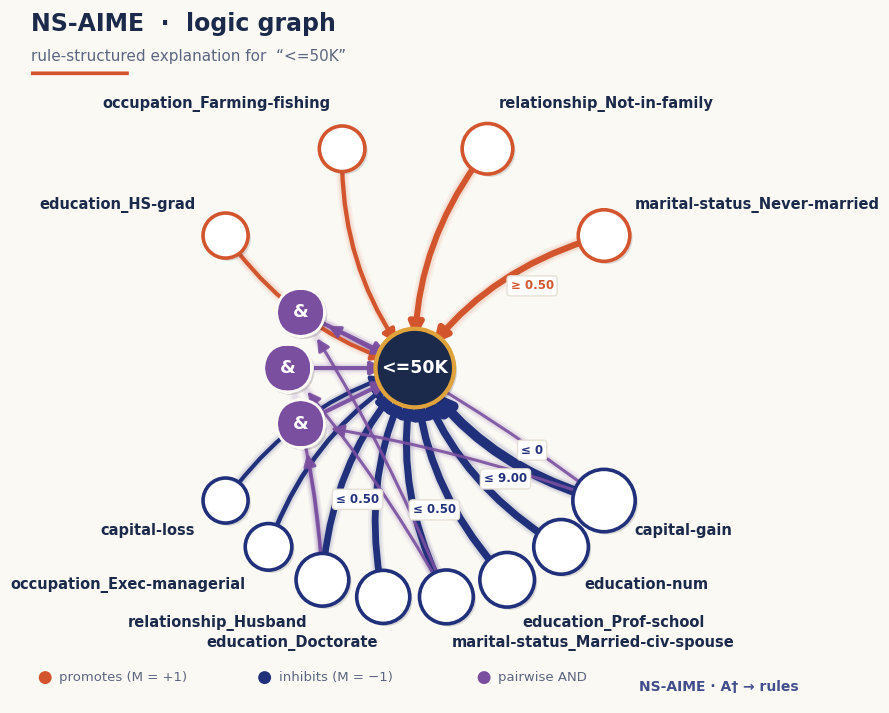

saved: /content/results/ns_aime_tabular_rule_demo/adult_logic_le=50K.png


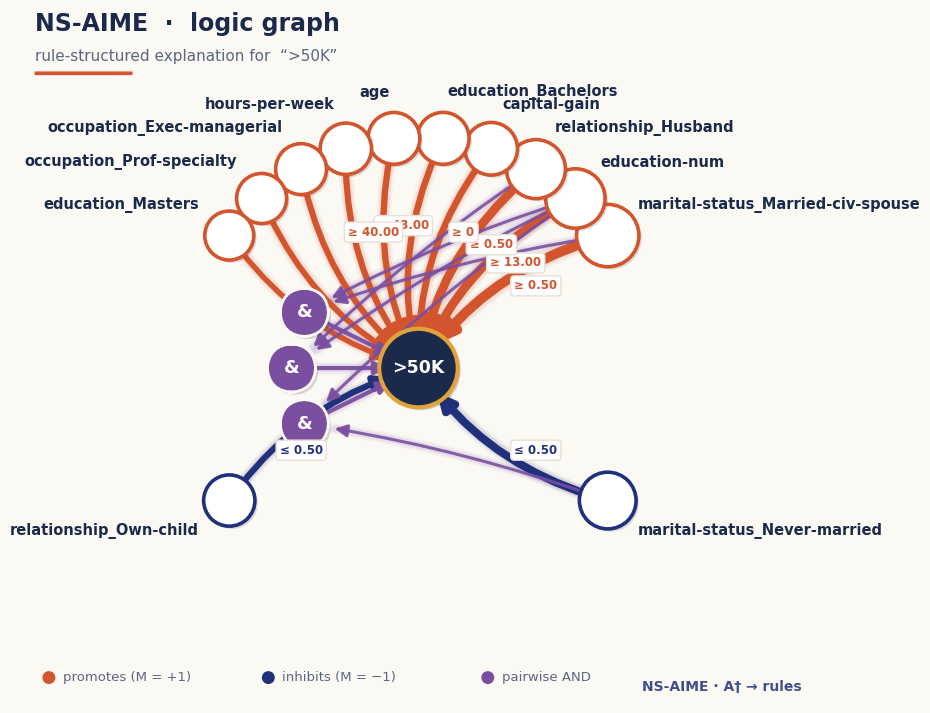

saved: /content/results/ns_aime_tabular_rule_demo/adult_logic_gt50K.png


In [8]:

# ============================================================
# 6. Static explanation graphs
# ============================================================
for k, cname in enumerate(class_names):
    save_path = os.path.join(RESULTS, f"adult_logic_{cname.replace('>', 'gt').replace('<', 'le')}.png")

    plot_logic_graph(
        B,
        ex.rules_,
        feature_names,
        class_index=k,
        class_name=cname,
        top_k=12,
        save_path=save_path,
    )

    print("saved:", save_path)



 <=50K


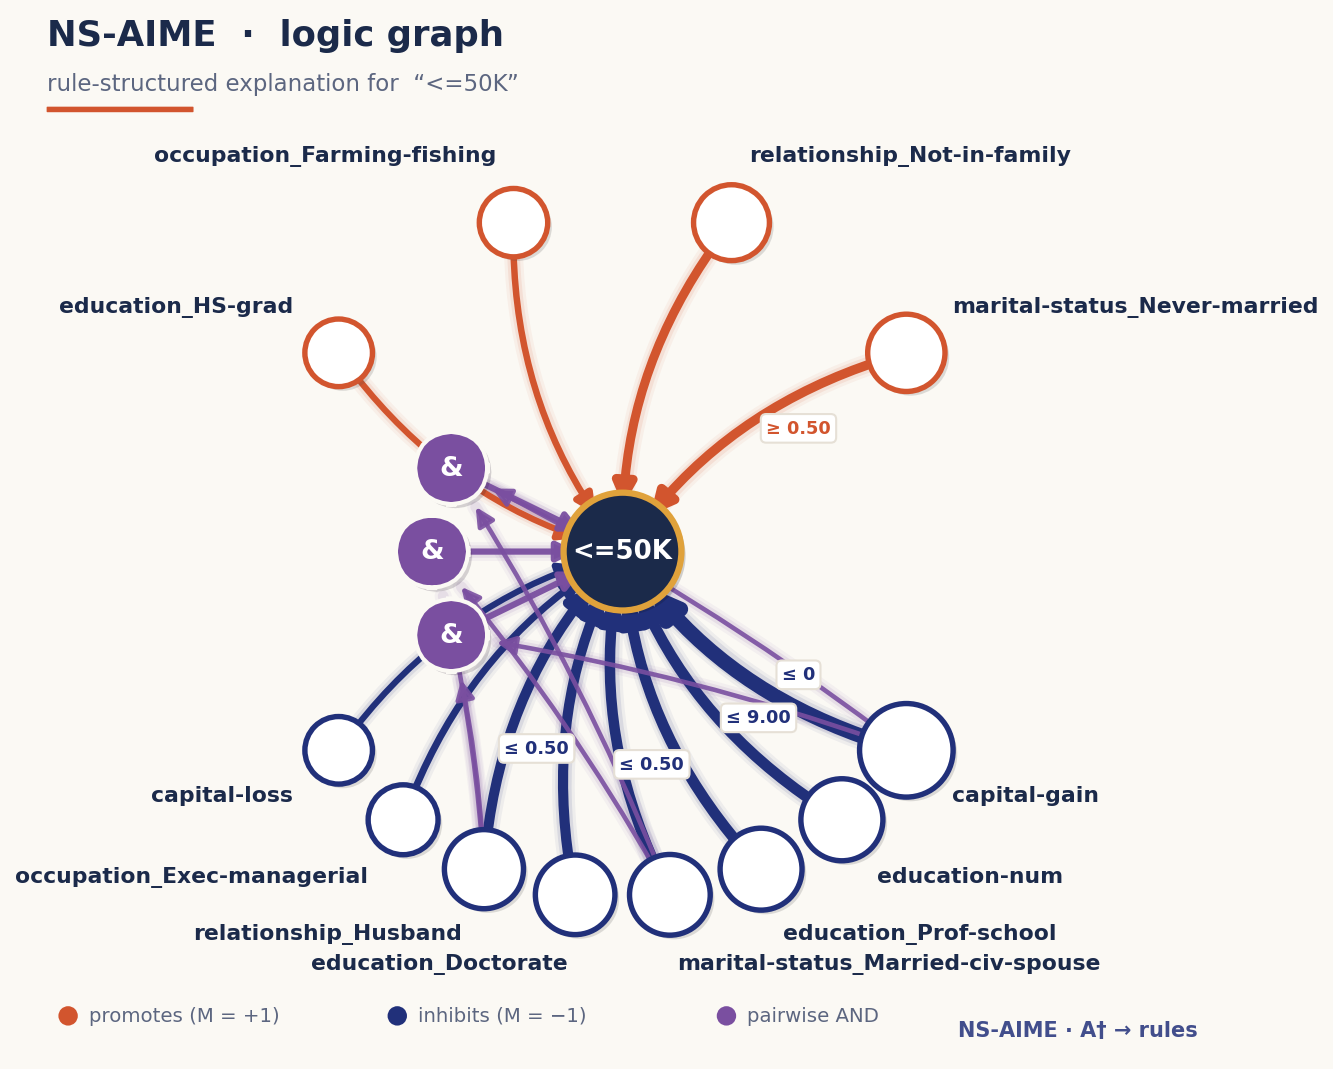


 >50K


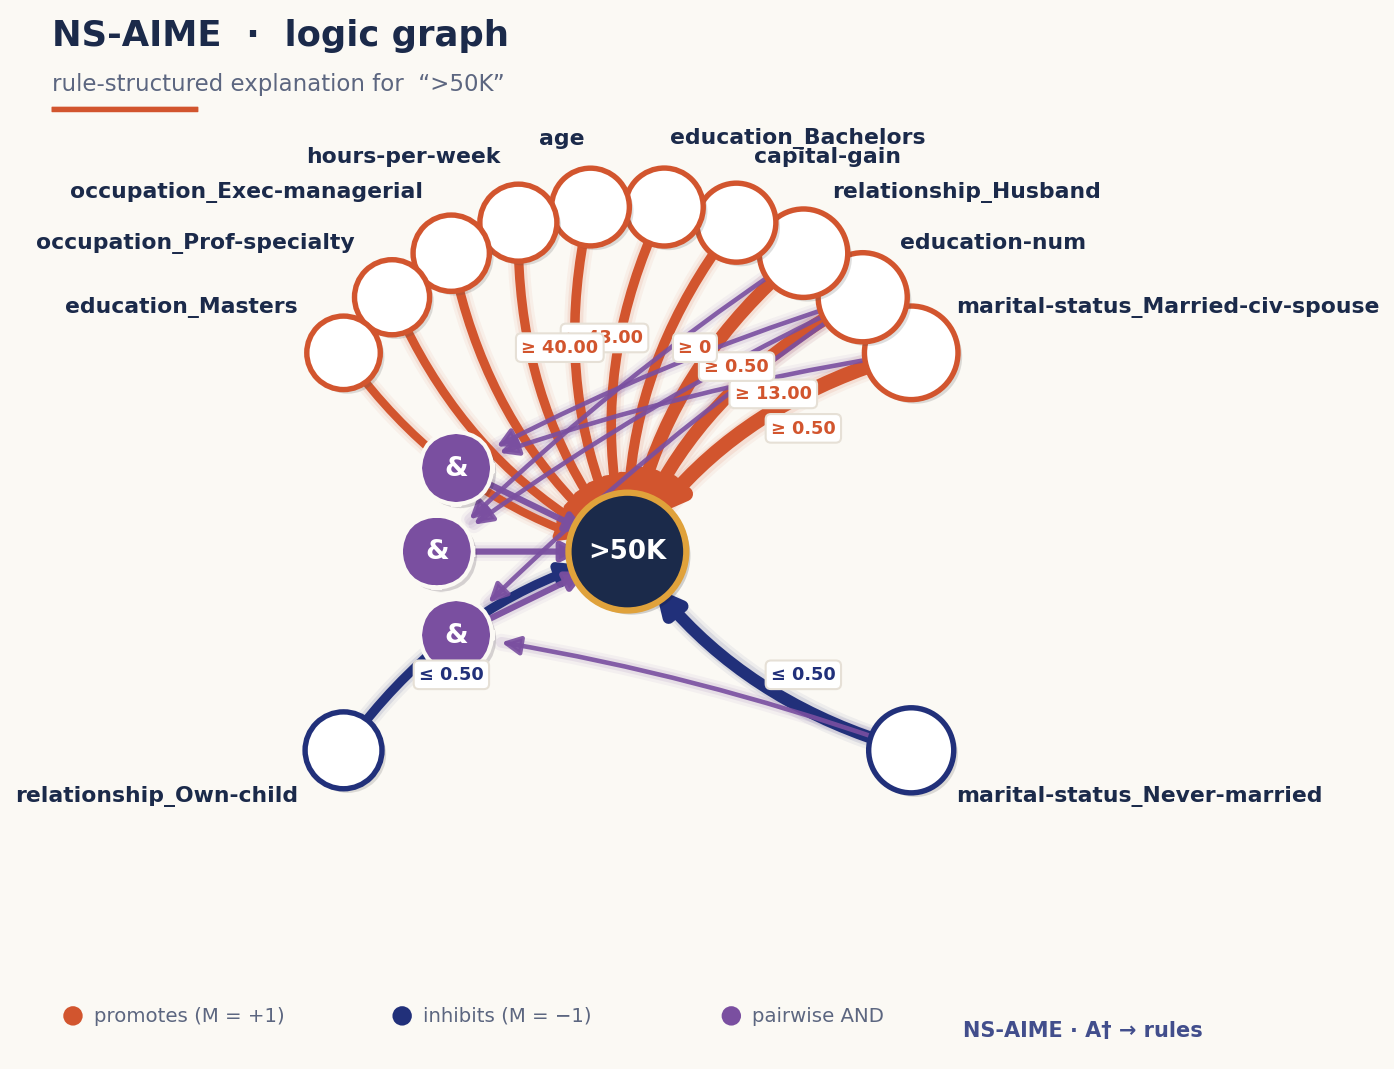

In [9]:

# Display saved graphs in Colab
from IPython.display import Image, display

for k, cname in enumerate(class_names):
    save_path = os.path.join(RESULTS, f"adult_logic_{cname.replace('>', 'gt').replace('<', 'le')}.png")
    print("\n", cname)
    display(Image(filename=save_path))



## 6. Dual Reporting: Raw AIME vs. NS-AIME

The constrained graph-based explanation should not be shown alone.

NS-AIME keeps both:

- \(A^\dagger\): raw AIME inverse explanation
- \(B^\*\): rule-guided constrained explanation

Large differences are interpreted as audit signals.


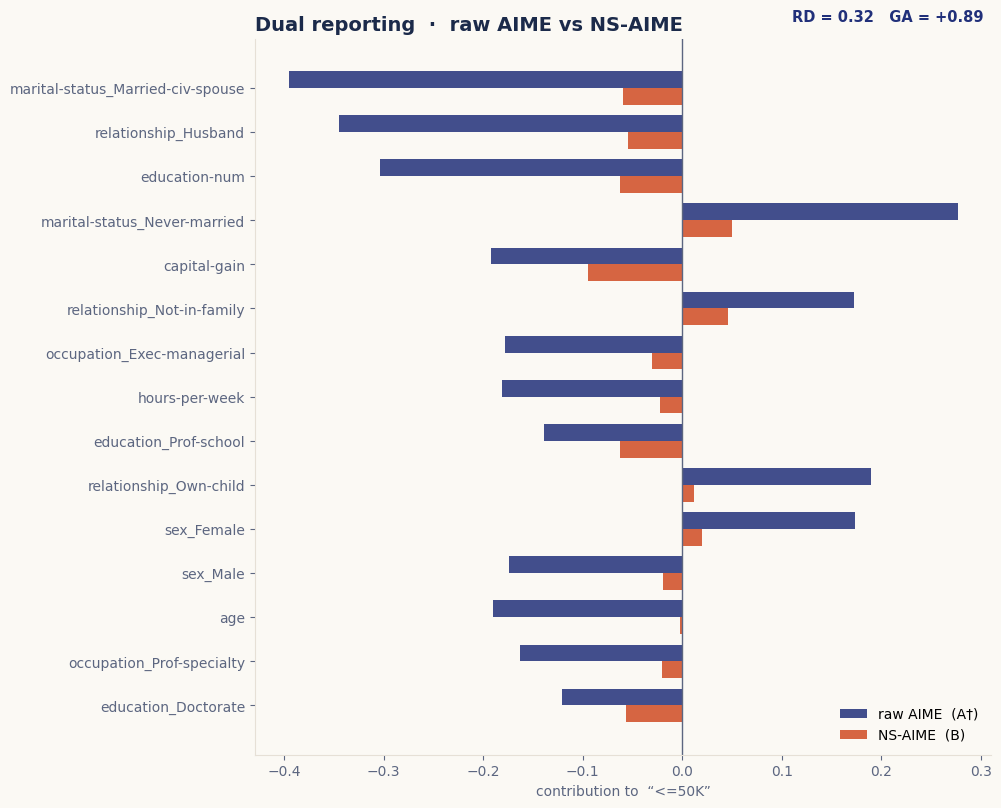

saved: /content/results/ns_aime_tabular_rule_demo/adult_dual_report_le=50K.png


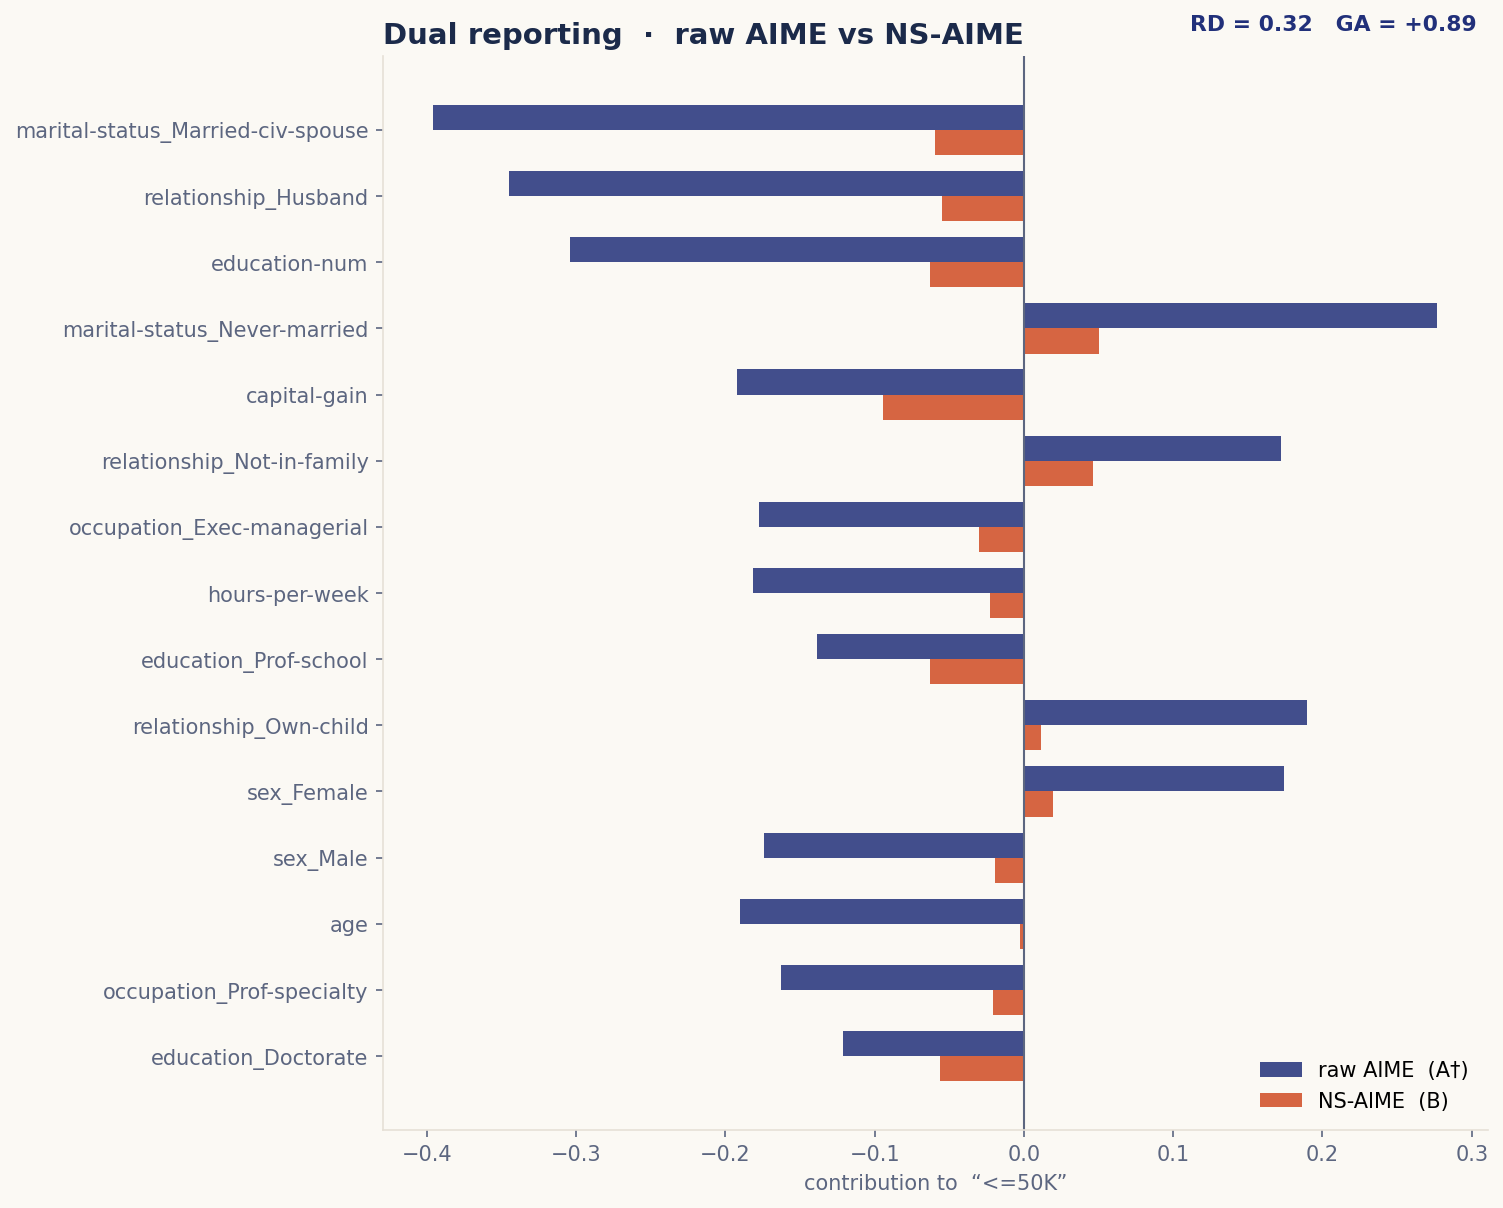

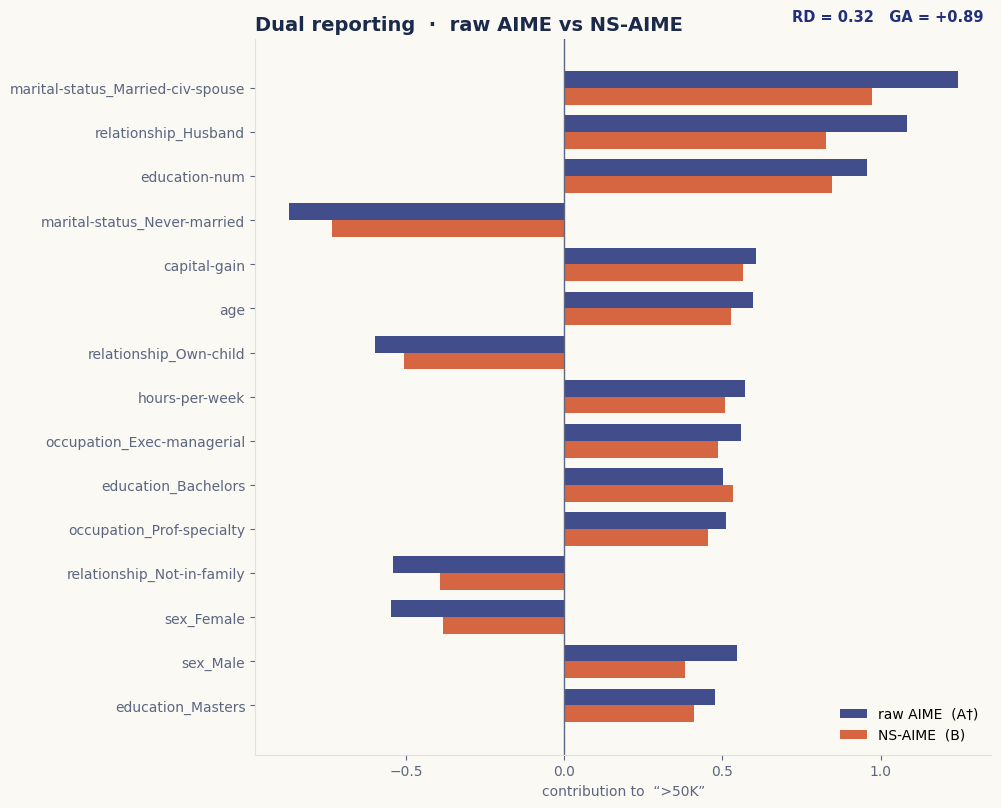

saved: /content/results/ns_aime_tabular_rule_demo/adult_dual_report_gt50K.png


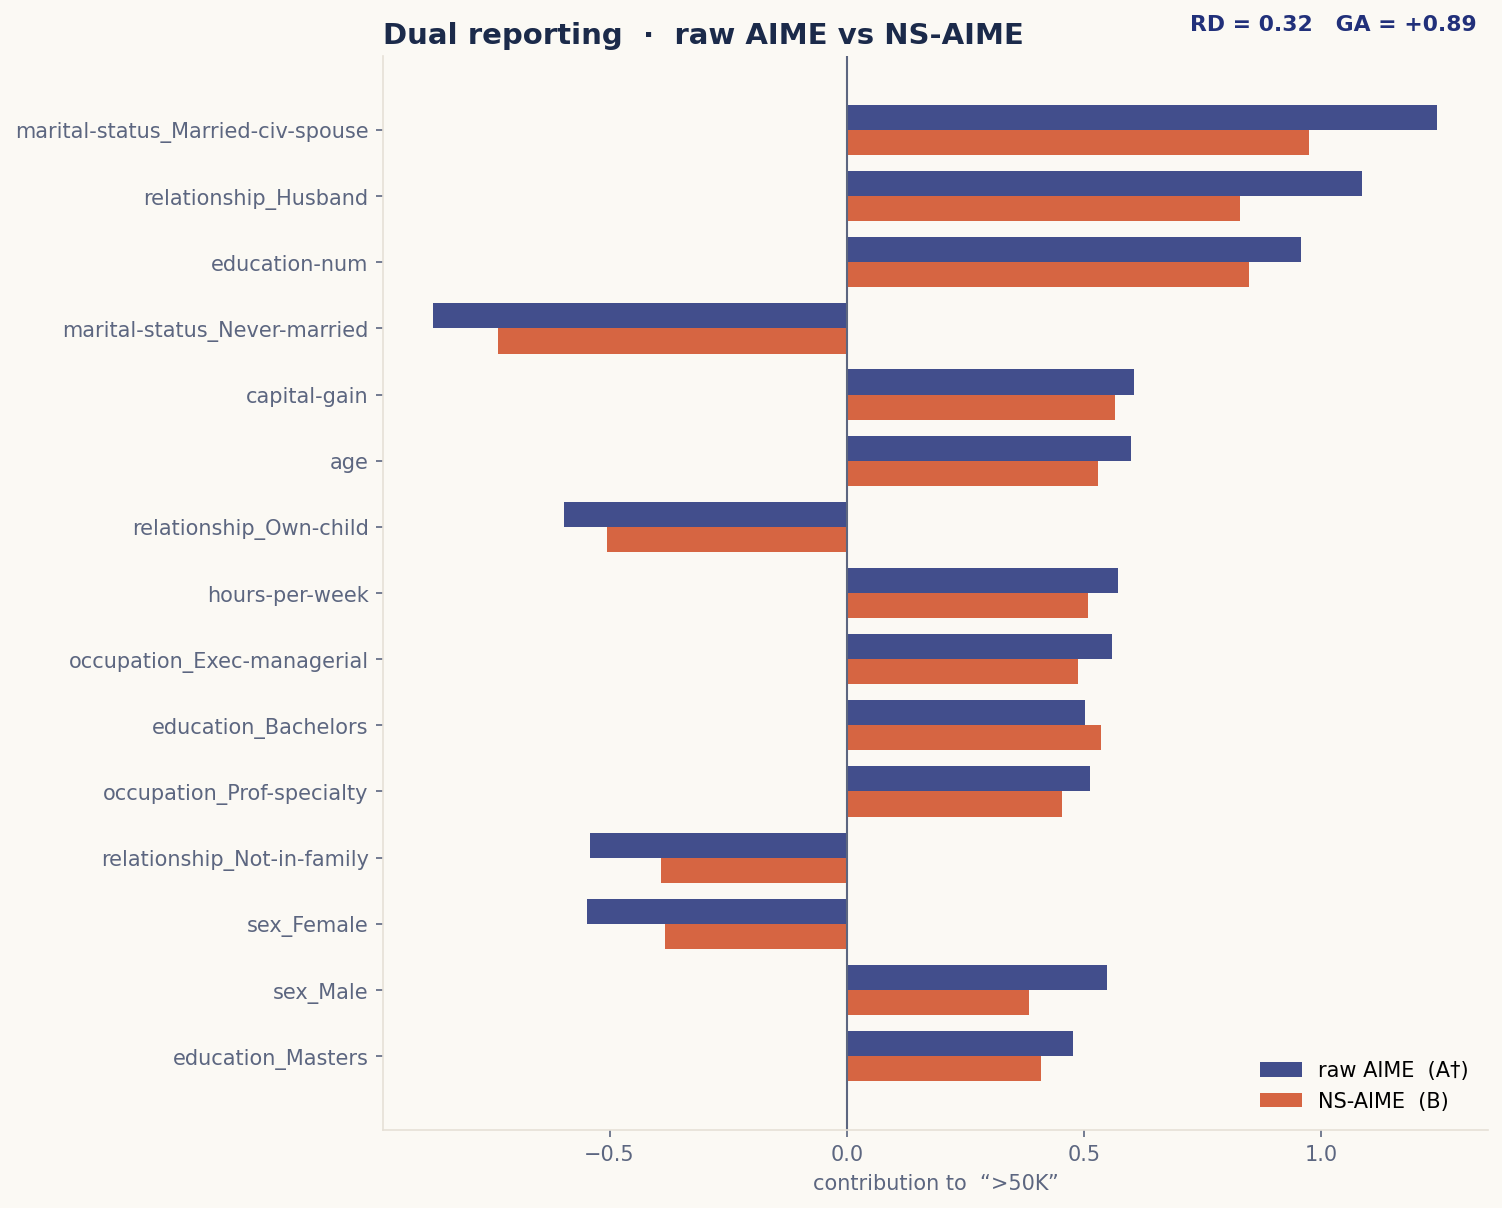

In [10]:

# ============================================================
# 7. Dual reporting bar plot
# ============================================================
for k, cname in enumerate(class_names):
    save_path = os.path.join(RESULTS, f"adult_dual_report_{cname.replace('>', 'gt').replace('<', 'le')}.png")

    plot_dual_report(
        ex.A_dagger_,
        B,
        feature_names,
        class_index=k,
        class_name=cname,
        rd=ns["rd"],
        ga=ns["ga"],
        top_k=15,
        save_path=save_path,
    )

    print("saved:", save_path)
    display(Image(filename=save_path))



## 7. Interactive Graph for Google Colab

Colab can be unstable with `IFrame(src=relative_path)`.  
The following cell reads the HTML file and embeds it as base64.


In [11]:

# ============================================================
# 8. Interactive HTML visualization for Colab
# ============================================================
from IPython.display import HTML, display
import base64

path = os.path.join(RESULTS, "adult_interactive.html")

render_logic_graph_html(
    B,
    ex.A_dagger_,
    ex.rules_,
    feature_names,
    class_names,
    metrics=ns,
    raw_metrics=raw,
    top_k=8,
    path=path,
    title=f"NS-AIME · Adult Income · {selected_name}",
)

print("wrote:", path)

with open(path, "r", encoding="utf-8") as f:
    html = f.read()

b64 = base64.b64encode(html.encode("utf-8")).decode("utf-8")

display(HTML(f'''
<iframe
    src="data:text/html;base64,{b64}"
    width="100%"
    height="720"
    style="border:1px solid #ddd; border-radius:8px;">
</iframe>
'''))


wrote: /content/results/ns_aime_tabular_rule_demo/adult_interactive.html



## 8. Optional: Download Results

Use this if you want to open the interactive graph in a browser or include the figures in a poster.


In [12]:

# Optional download in Colab
try:
    from google.colab import files
    files.download(path)
except Exception:
    print("Not running in Colab, or download skipped.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


## 9. Interpretation Guide

Use the following wording for the poster/demo:

> NS-AIME does not aim to learn a complete logical rule system.  
> It targets a minimal set of symbolic structures that can transform the AIME explanation matrix into a human-readable and auditable Explanation Graph.

The graph improves readability by organizing feature contributions, threshold conditions, and pairwise AND relations as directed explanatory edges.

At the same time, the graph is always checked against the original AIME matrix \(A^\dagger\).  
Therefore, NS-AIME does not hide the original numerical explanation, but makes the gap between the raw matrix and the graph-based constrained explanation visible.
